In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/Male baboons GC and T3 Anonymized.csv")
## Cleaning the dataset


# Removing completely empty rows or columns
df = df.dropna(how='all')          # drop rows that are fully empty
df = df.dropna(axis=1, how='all')  # drop columns that are fully empty

# Remove unnamed index-like columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,Male_ID,Group_ID,Collection_date,Hydroyear,T3_conc,GC_conc,Season,Rainfall,Tav,Group_size,Hierarchy_stability,T3_storage,GC_storage,Age,Alpha_status,Ordinal_rank,Consortships,Aggression,Genetic_ancestry
0,110,F,11/4/2004,2005,66.73,29.06,short rain,8.0,24.0,6,stable,16.73,0.78,12.11,non-alpha,6,0.0,-0.27,0.240
1,19,F,11/4/2004,2005,104.48,38.89,short rain,8.0,24.0,6,stable,16.73,0.78,8.23,non-alpha,3,34.0,-0.27,0.531
2,172,D,11/5/2004,2005,133.03,64.19,short rain,8.0,24.1,8,unstable,16.74,0.77,7.88,alpha,1,0.0,-0.33,0.517
3,116,D,11/5/2004,2005,77.25,27.78,short rain,8.0,24.1,8,unstable,16.72,0.77,7.95,non-alpha,2,0.0,-0.03,0.617
4,63,D,11/5/2004,2005,109.12,74.61,short rain,8.0,24.1,8,unstable,16.74,0.77,6.80,non-alpha,6,0.0,0.15,0.795


In [4]:
#exporting the cleaned dataset

df.to_csv("cleaned_baboon_data.csv", index=False)

In [5]:
##Summary statistics

numeric = df.select_dtypes(include=[np.number])
summary_stats = pd.DataFrame({
    "mean": numeric.mean(),
    "median": numeric.median(),
    "std": numeric.std(),
    "min": numeric.min(),
    "max": numeric.max(),
    "range": numeric.max() - numeric.min()
})

summary_stats

,mean,median,std,min,max,range
Male_ID,110.390888,113.00,54.807939,1.000,204.000,203.000
Hydroyear,2011.252714,2011.00,3.671307,2005.000,2018.000,13.000
T3_conc,119.588369,110.12,57.612649,17.840,1557.820,1539.980
GC_conc,79.939791,71.83,41.104079,13.110,471.360,458.250
Rainfall,25.180115,8.00,37.513546,0.000,278.000,278.000
Tav,23.502044,23.90,1.497674,19.800,26.500,6.700
Group_size,10.675112,10.00,3.910526,3.000,21.000,18.000
T3_storage,9.021776,9.44,4.078967,0.860,16.740,15.880
GC_storage,0.959001,0.87,0.406278,0.240,2.280,2.040
Age,12.290573,11.67,3.212922,6.800,25.120,18.320


## Histograms and Boxplots for ALL numeric variables

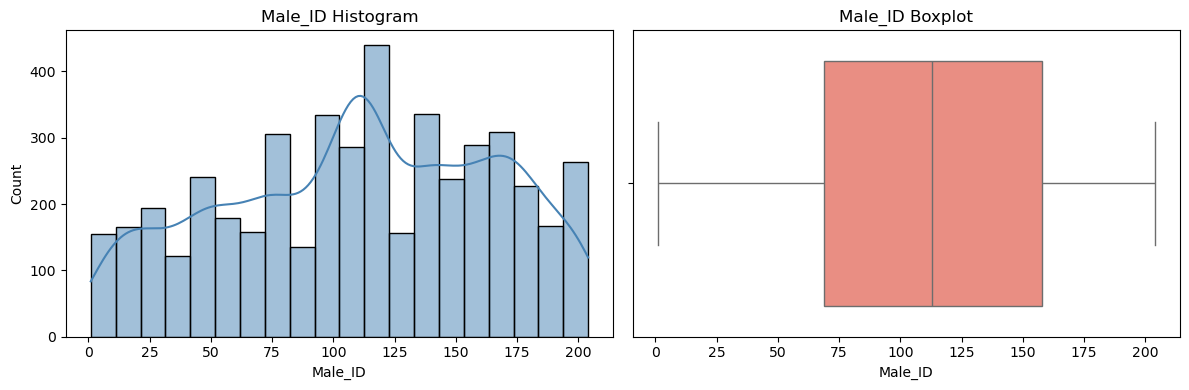

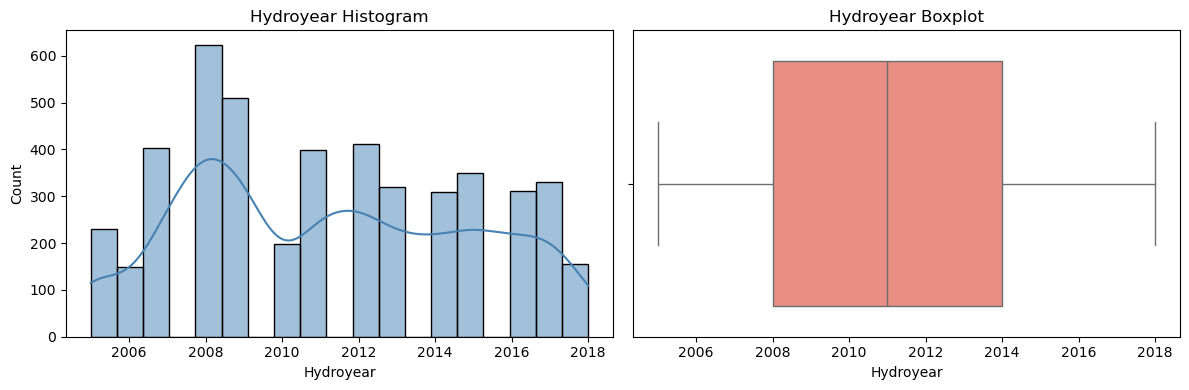

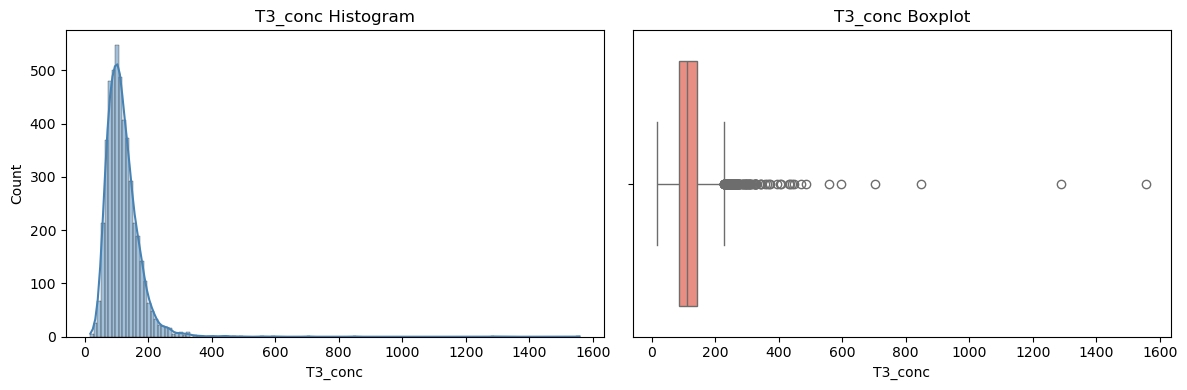

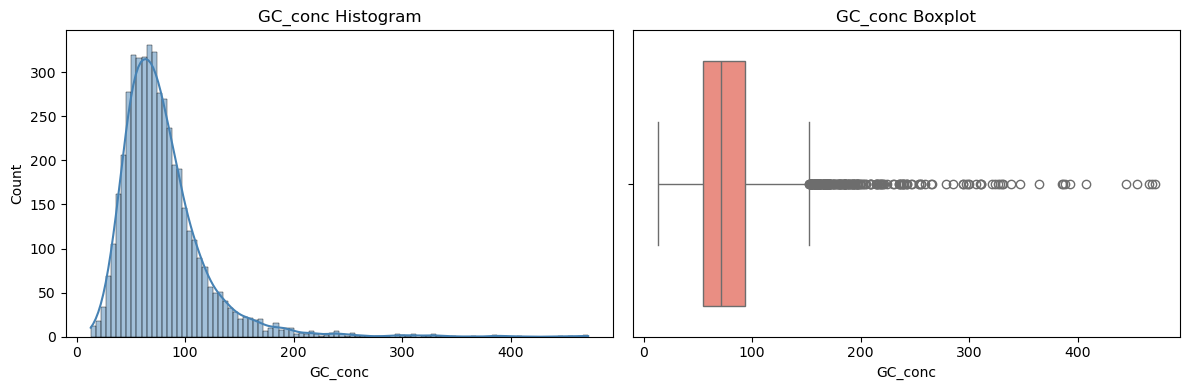

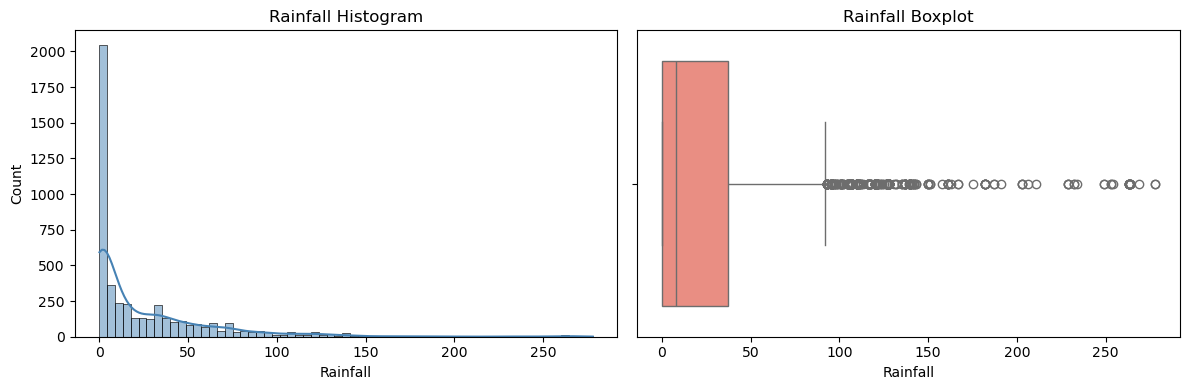

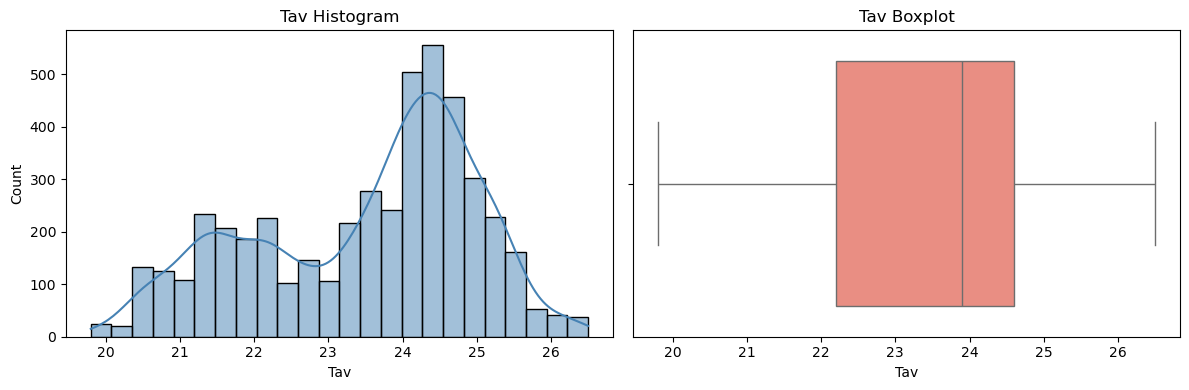

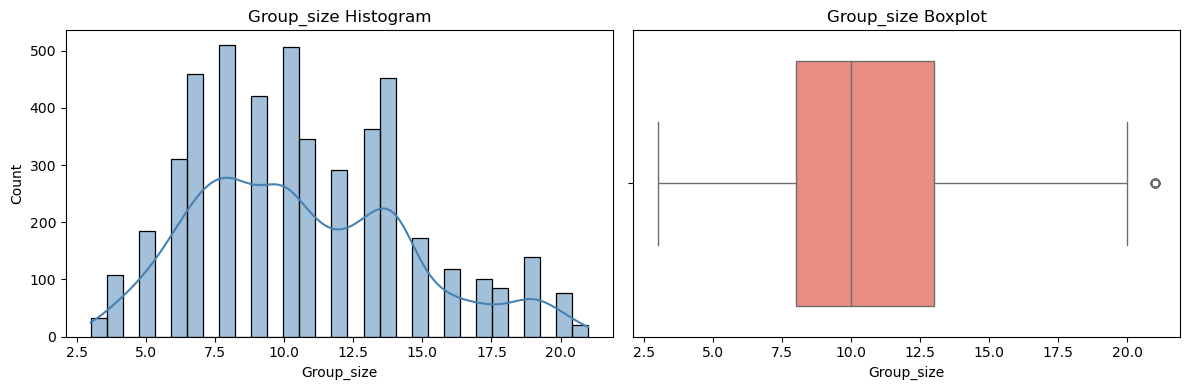

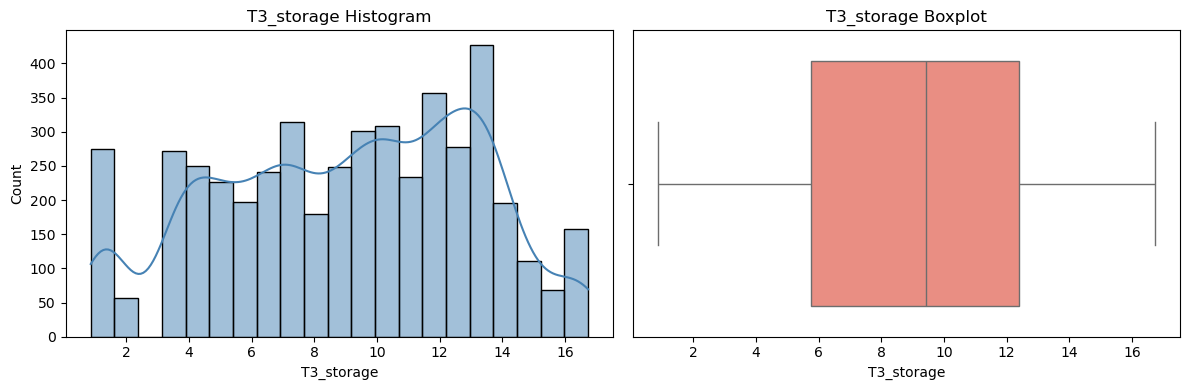

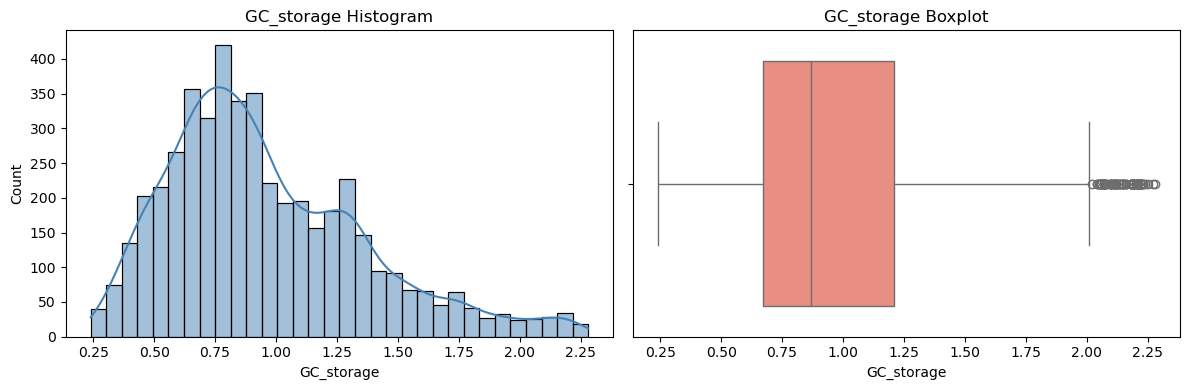

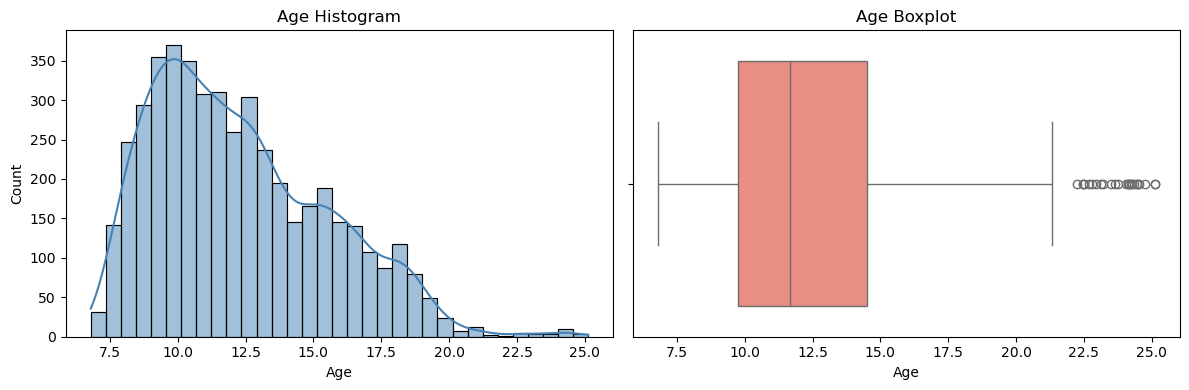

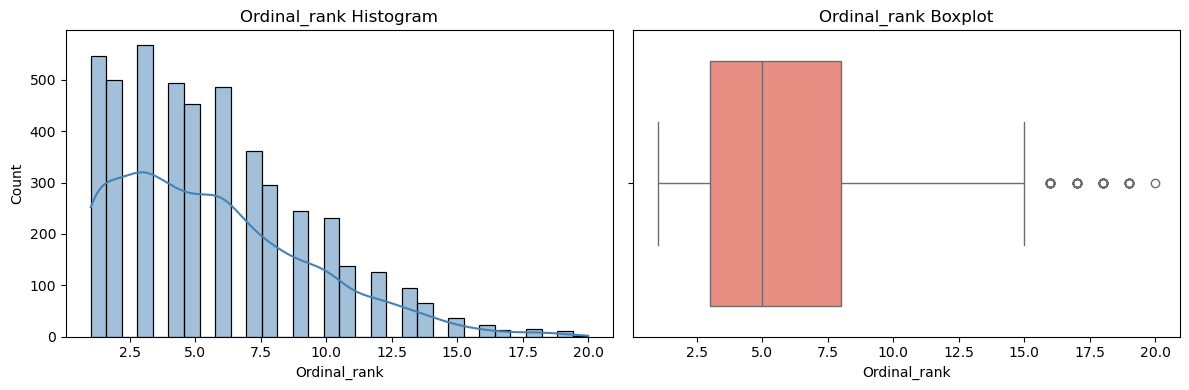

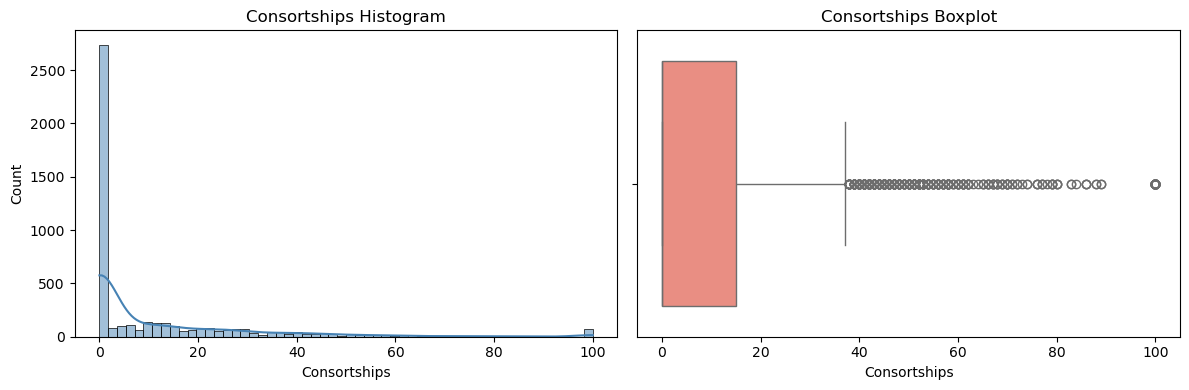

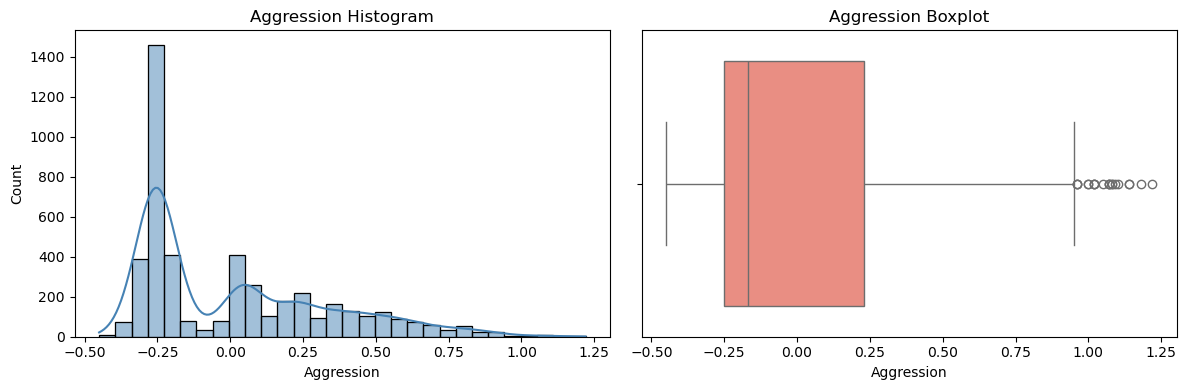

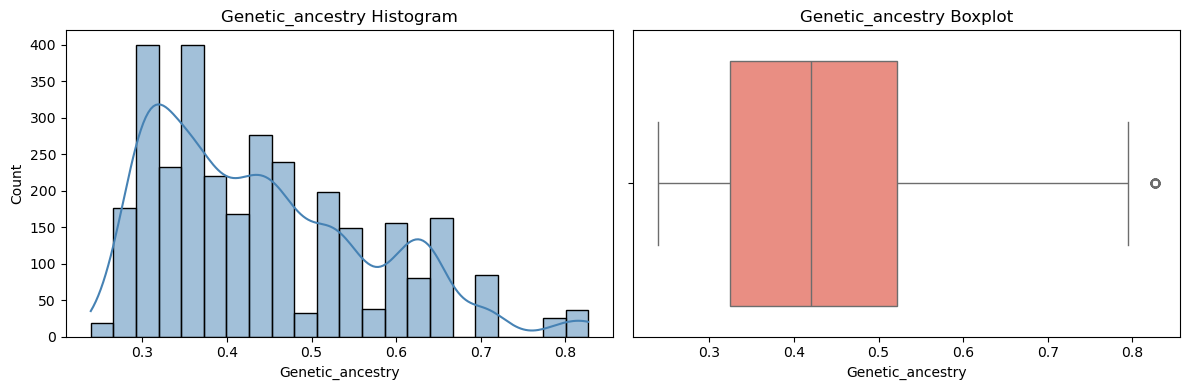

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=ax[0], color="steelblue")
    ax[0].set_title(f"{col} Histogram")

    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1], color="salmon")
    ax[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

## Boxplots of Hormone Levels by Social Rank

/var/folders/mh/06__kt913252938nc4rczrk40000gn/T/ipykernel_67811/3531450460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")


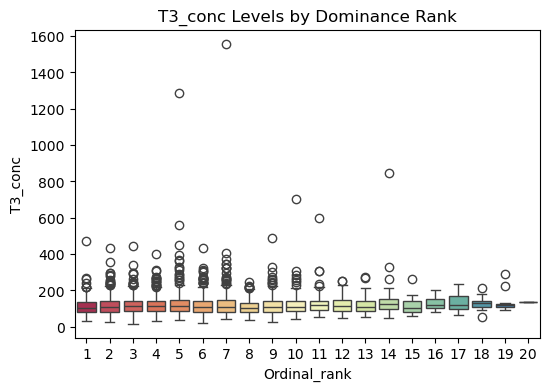

/var/folders/mh/06__kt913252938nc4rczrk40000gn/T/ipykernel_67811/3531450460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")


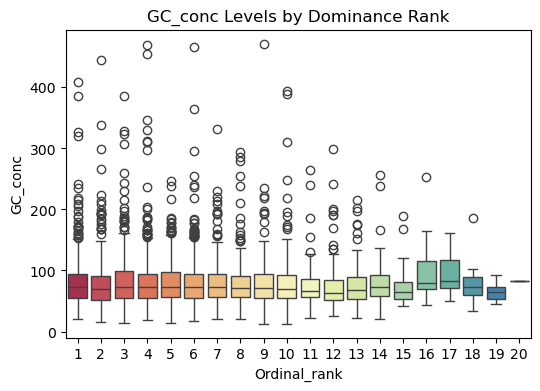

In [7]:
hormones = ["T3_conc", "GC_conc"]  

for h in hormones:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Ordinal_rank", y=h, data = df, palette="Spectral")
    plt.title(f"{h} Levels by Dominance Rank")
    plt.show()


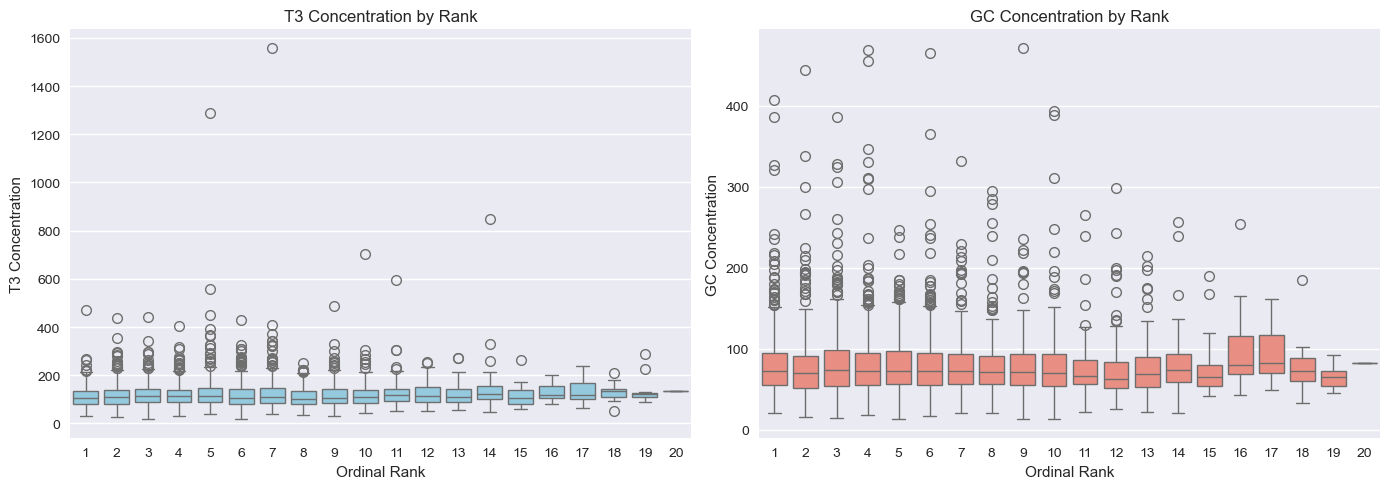

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x="Ordinal_rank",
    y="T3_conc",
    data=df,
    color="skyblue",
    ax=ax[0]
)
ax[0].set_title("T3 Concentration by Rank")
ax[0].set_xlabel("Ordinal Rank")
ax[0].set_ylabel("T3 Concentration")

sns.boxplot(
    x="Ordinal_rank",
    y="GC_conc",
    data=df,
    color="salmon",
    ax=ax[1]
)
ax[1].set_title("GC Concentration by Rank")
ax[1].set_xlabel("Ordinal Rank")
ax[1].set_ylabel("GC Concentration")

plt.tight_layout()
plt.show()


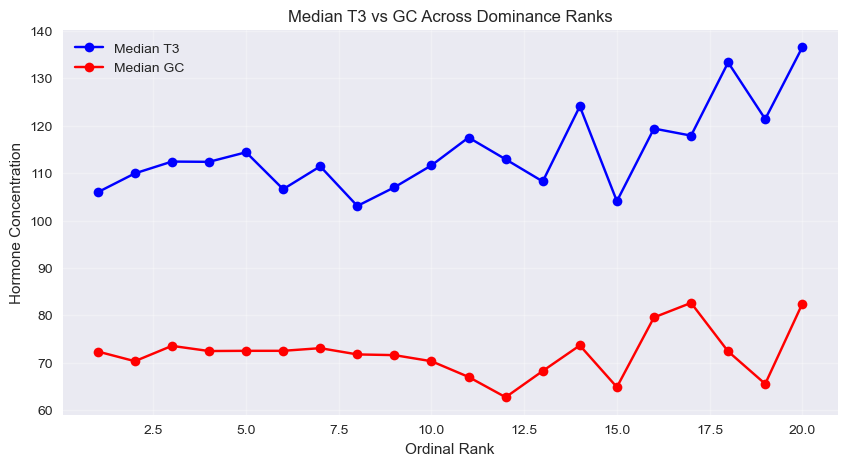

In [9]:
##Direct comparison of Median T3 and Median GC Across Ranks

rank_summary = df.groupby("Ordinal_rank")[["T3_conc", "GC_conc"]].median()

plt.figure(figsize=(10,5))
plt.plot(rank_summary.index, rank_summary["T3_conc"], marker="o", label="Median T3", color="blue")
plt.plot(rank_summary.index, rank_summary["GC_conc"], marker="o", label="Median GC", color="red")

plt.title("Median T3 vs GC Across Dominance Ranks")
plt.xlabel("Ordinal Rank")
plt.ylabel("Hormone Concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


I like this because it shows the different patterns of T3 and GC across ranks. 
- T3 line rises at certainn ranks likely because of more aggression, mate guarding, or competition for resources which increase metabolic rate.
- T3 peaks in the lower ranks
- GC line is mostly flat.
- Stress levels are not as varied across ranks compared to T3.

## Analysis

In [10]:
#using linear regression

from sklearn.linear_model import LinearRegression

X = df[['Ordinal_rank']]
y_T3 = df['T3_conc']
y_gc = df['GC_conc']

model_T3 = LinearRegression()
model_T3.fit(X, y_T3)

model_gc = LinearRegression()
model_gc.fit(X, y_gc)

#find coefficients
print("T3 slope:", model_T3.coef_[0])
print("T3 intercept:", model_T3.intercept_)
print()

print("Glucocorticoid slope:", model_gc.coef_[0])
print("Glucocorticoid intercept:", model_gc.intercept_)
print()

# R^2
print("T3 R^2:", model_T3.score(X, y_T3))
print("Glucocorticoid R^2:", model_gc.score(X, y_gc))

T3 slope: 0.6720219200829967
T3 intercept: 115.78987865525153

Glucocorticoid slope: -0.14484787664221863
Glucocorticoid intercept: 80.7585195394878

T3 R^2: 0.0018401524454575435
Glucocorticoid R^2: 0.0001679488509450655


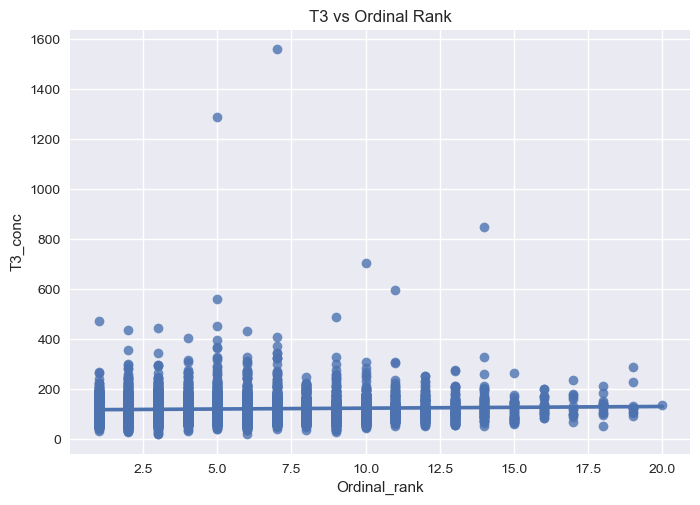

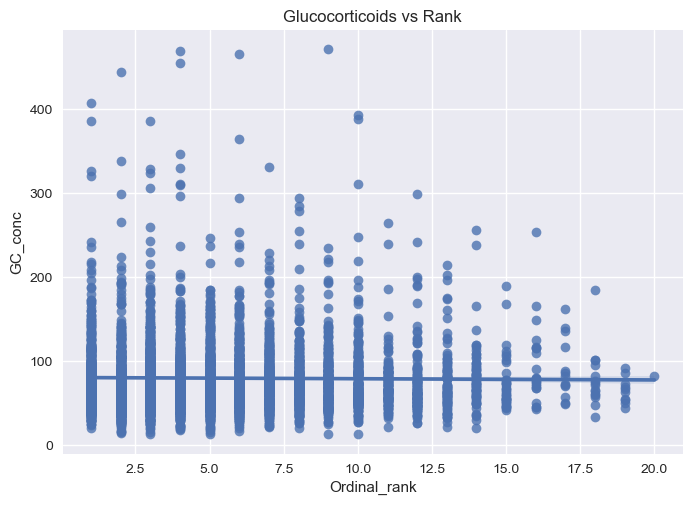

In [11]:
#visual
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x = 'Ordinal_rank', y = 'T3_conc', data = df)
plt.title("T3 vs Ordinal Rank")
plt.show()

sns.regplot(x = 'Ordinal_rank', y = 'GC_conc', data = df)
plt.title("Glucocorticoids vs Rank")
plt.show()

#### Both R^2's were very small, showing that T3 only explained 0.18% of the variation and GC only explained 0.016% of the variation. There is no strong evidence that rank meaningfully predicts stress levels in baboons.

## Analysis Exploration

Rank 1 (alpha) median GC: 72.375
Rank 2-5 median GC: 72.28999999999999
Rank 6+ median GC: 71.36

Rank 1 (alpha) median T3: 105.975
Rank 2-5 median T3: 111.86
Rank 6+ median T3: 109.44

Rank 1 (alpha) mean GC: 81.18034798534799
Rank 2-5 mean GC: 80.31304865938431
Rank 6+ mean GC: 79.27105755732335

Rank 1 (alpha) mean T3: 111.50600732600732
Rank 2-5 mean T3: 121.05097318768618
Rank 6+ mean T3: 120.27497894244267

                                  GC_conc  T3_conc
Alpha_status Hierarchy_stability                  
alpha        stable                73.930   107.10
             unstable              71.590   105.33
non-alpha    stable                70.230   113.97
             unstable              73.095   109.09



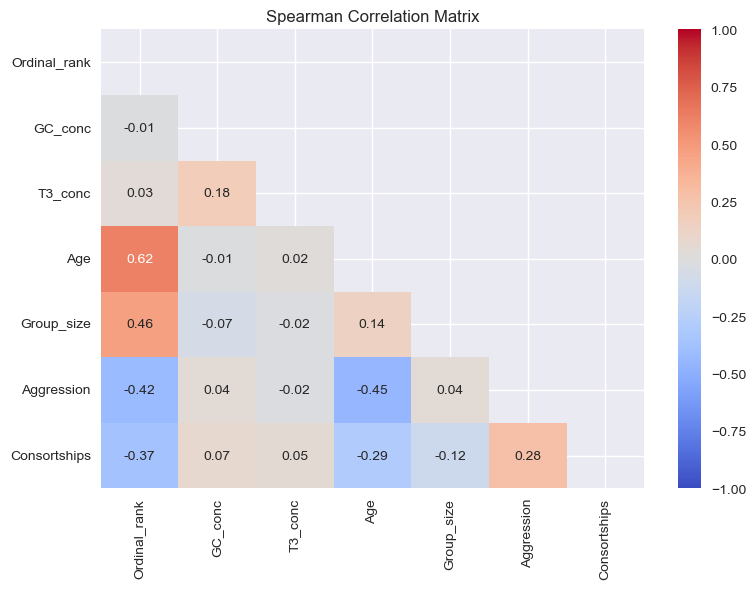

In [63]:
#check rank 1 vs others for alpha anomaly
rank1 = df[df['Ordinal_rank']== 1]
rank2_5 = df[df['Ordinal_rank'].between(2,5)]
low_rank = df[df['Ordinal_rank'] >= 6]

print('Rank 1 (alpha) median GC:', rank1['GC_conc'].median())
print('Rank 2-5 median GC:', rank2_5['GC_conc'].median())
print('Rank 6+ median GC:', low_rank['GC_conc'].median())
print()
print('Rank 1 (alpha) median T3:', rank1['T3_conc'].median())
print('Rank 2-5 median T3:', rank2_5['T3_conc'].median())
print('Rank 6+ median T3:', low_rank['T3_conc'].median())
print()

print('Rank 1 (alpha) mean GC:', rank1['GC_conc'].mean())
print('Rank 2-5 mean GC:', rank2_5['GC_conc'].mean())
print('Rank 6+ mean GC:', low_rank['GC_conc'].mean())
print()
print('Rank 1 (alpha) mean T3:', rank1['T3_conc'].mean())
print('Rank 2-5 mean T3:', rank2_5['T3_conc'].mean())
print('Rank 6+ mean T3:', low_rank['T3_conc'].mean())
print()

#alpha vs. non-alpha in stable vs unstable
grp = df.groupby(['Alpha_status', 'Hierarchy_stability'])[['GC_conc','T3_conc']].median()
print(grp)
print()

#spearman correlation rank vs GC/T3
cols = ['Ordinal_rank', 'GC_conc', 'T3_conc', 'Age', 'Group_size',
        'Aggression', 'Consortships']

corr_matrix = df[cols].corr(method='spearman')

# Mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

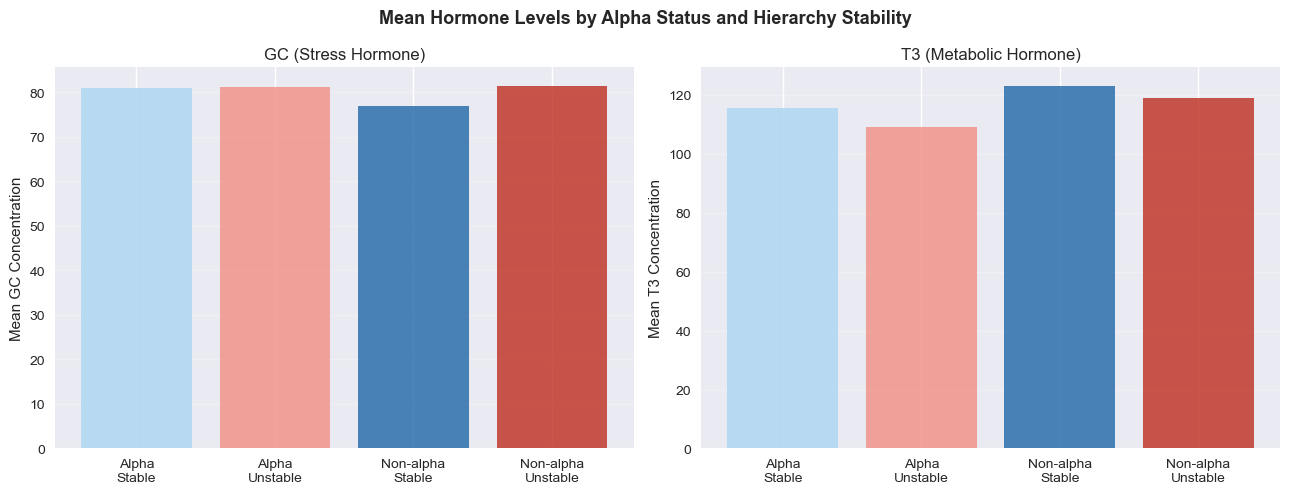

In [33]:
df['is_alpha']    = (df['Alpha_status'] == 'alpha').astype(int)
df['is_unstable'] = (df['Hierarchy_stability'] == 'unstable').astype(int)

# ── Linear Regression ─────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression

X = df[['is_alpha', 'is_unstable']]
y_gc = df['GC_conc']
y_t3 = df['T3_conc']

model_gc = LinearRegression().fit(X, y_gc)
model_t3 = LinearRegression().fit(X, y_t3)

# ── Chart ─────────────────────────────────────────────────────────────────
combos = [('alpha','stable'), ('alpha','unstable'),
          ('non-alpha','stable'), ('non-alpha','unstable')]
labels = ['Alpha\nStable', 'Alpha\nUnstable', 'Non-alpha\nStable', 'Non-alpha\nUnstable']
colors = ['#AED6F1', '#F1948A', '#2C6FAC', '#C0392B']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mean Hormone Levels by Alpha Status and Hierarchy Stability',
             fontsize=13, fontweight='bold')

# GC chart
gc_means = [df[(df.Alpha_status==a) & (df.Hierarchy_stability==s)]['GC_conc'].mean()
            for a, s in combos]
ax1.bar(labels, gc_means, color=colors, alpha=0.85)
ax1.set_ylabel('Mean GC Concentration')
ax1.set_title('GC (Stress Hormone)')
ax1.grid(axis='y', alpha=0.25)

# T3 chart
t3_means = [df[(df.Alpha_status==a) & (df.Hierarchy_stability==s)]['T3_conc'].mean()
            for a, s in combos]
ax2.bar(labels, t3_means, color=colors, alpha=0.85)
ax2.set_ylabel('Mean T3 Concentration')
ax2.set_title('T3 (Metabolic Hormone)')
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

From article's supplemental materials: "We found no evidence that genetic ancestry predicted male mT3
or fGC concentrations (see supplementary Table S1 and S2), so we did not include genetic
ancestry estimates in the models presented in this paper"

Therefore, I didn't include genetic ancestry in analysis

Text(0.5, 1.0, 'Rank vs Aggression')

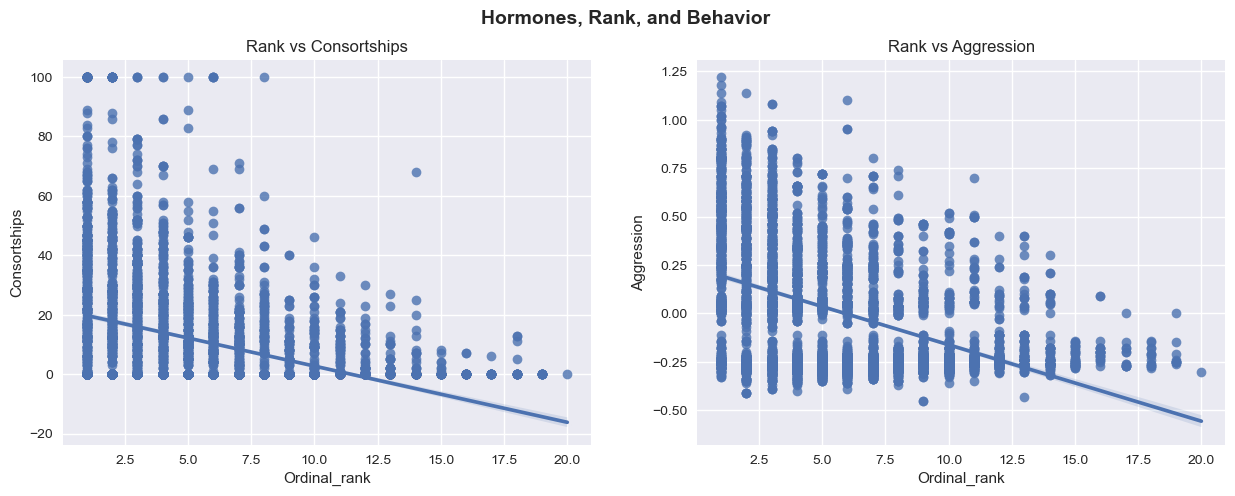

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Hormones, Rank, and Behavior', fontsize=14, fontweight='bold')

#rank and aggression/consortship graphs
sns.regplot(x='Ordinal_rank', y='Consortships', data=df, ax=axes[0])
axes[0].set_title('Rank vs Consortships')

sns.regplot(x='Ordinal_rank', y='Aggression', data=df, ax=axes[1])
axes[1].set_title('Rank vs Aggression')

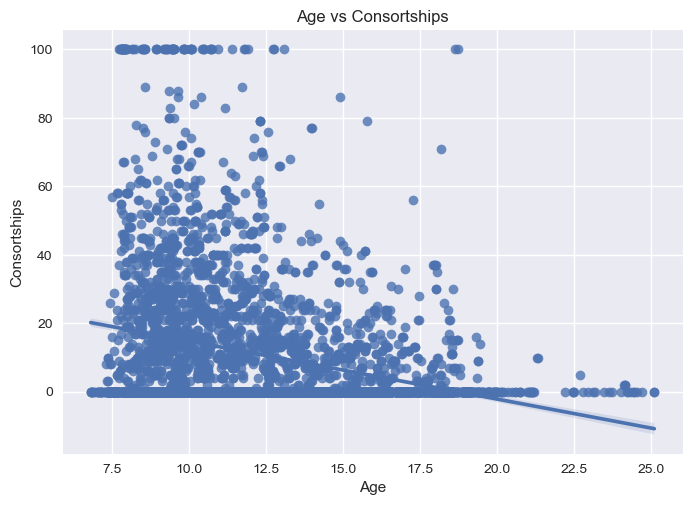

In [61]:
sns.regplot(x = 'Age', y = 'Consortships', data = df)
plt.title("Age vs Consortships")
plt.show()

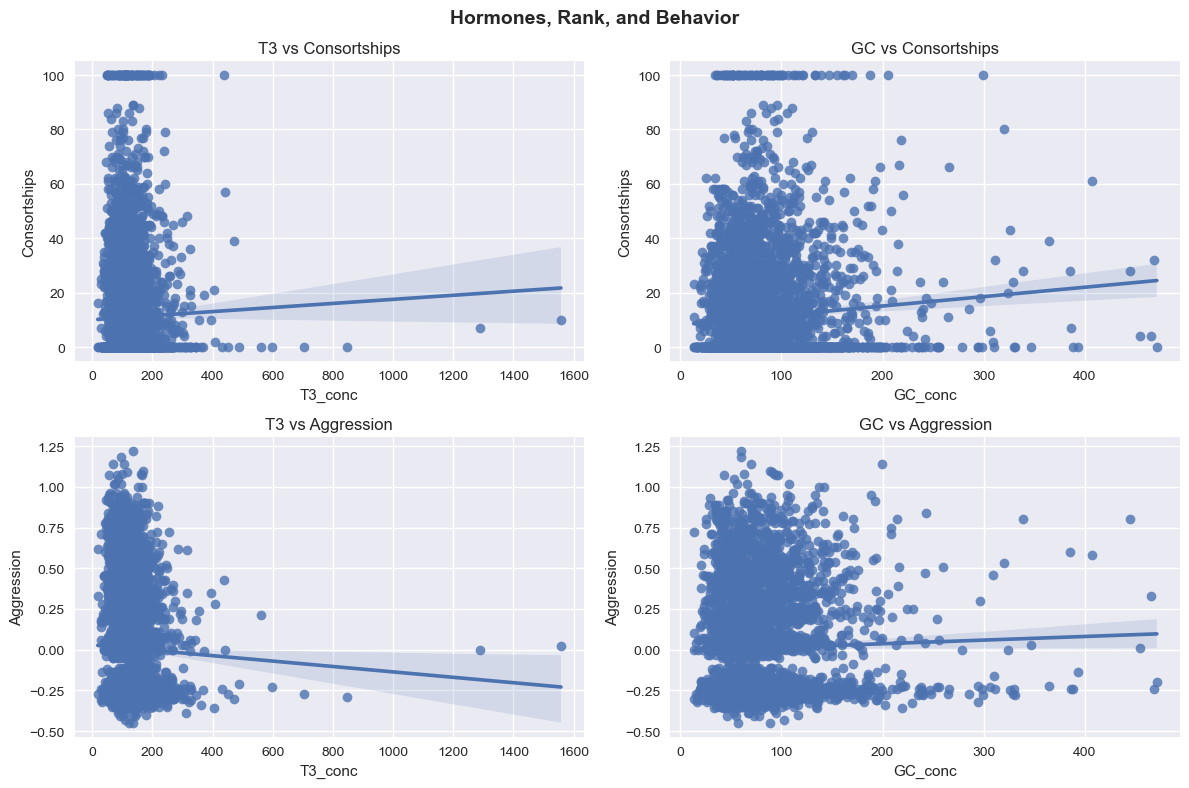

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Hormones, Rank, and Behavior', fontsize=14, fontweight='bold')

# Row 1: vs Consortships

sns.regplot(x='T3_conc', y='Consortships', data=df, ax=axes[0, 0])
axes[0, 0].set_title('T3 vs Consortships')

sns.regplot(x='GC_conc', y='Consortships', data=df, ax=axes[0, 1])
axes[0, 1].set_title('GC vs Consortships')

# Row 2: vs Aggression

sns.regplot(x='T3_conc', y='Aggression', data=df, ax=axes[1, 0])
axes[1, 0].set_title('T3 vs Aggression')

sns.regplot(x='GC_conc', y='Aggression', data=df, ax=axes[1, 1])
axes[1, 1].set_title('GC vs Aggression')

plt.tight_layout()
plt.show()

basically no correlation